In [1]:
import copy
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.irradiance import Irradiance
from spectra.utilities import ArrayParams, find_index_of_nearest, find_index_of_max
from spectra.normalizeddose import NormalizedDose
from spectra.sourcespectrum import SourceSpectrum

# Create resins

In [29]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
avobenzone = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    2.0
)
nps = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.0
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)
resin = Resin(monomers=pegda, absorbers=[avobenzone,nps], photoinitiators=irgacure819)
resin_nps = Resin(monomers=pegda, absorbers=nps)
resin_avo = Resin(monomers=pegda, absorbers=avobenzone)


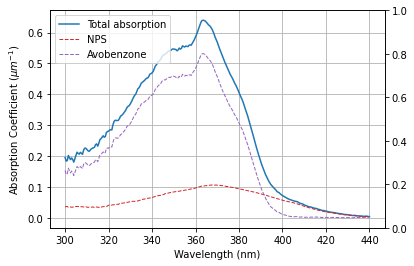

In [33]:
wavelengths = np.linspace(*ArrayParams(300, 440, 281))

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(wavelengths, resin.calc_absorption_coef_inv_um(wavelengths), label='Total absorption')
ax.plot(wavelengths, resin_nps.calc_absorption_coef_inv_um(wavelengths), c='C3', lw=1, ls='--', label='NPS')
ax.plot(wavelengths, resin_avo.calc_absorption_coef_inv_um(wavelengths), c='C4', lw=1, ls='--', label='Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
# ax.set_title(nps.name + '\n' + source.name)
# ax2.plot(wavelengths, source_365nm_shortpass.calc_power(wavelengths), c='C1', label='365 nm LED + filter')
# ax2.plot(wavelengths, source_385nm.calc_power(wavelengths), c='C2', lw=1, ls='--', label='385 nm LED')
# ax2.plot(wavelengths, source_385nm_filtered.calc_power(wavelengths), c='C2', label='385 nm LED + filter')
# ax2.set_ylabel('Normalized Power')
ax.legend(loc='upper left')
# ax2.legend(loc='upper right');
ax.grid()


# Normalized dose for filtered 365 nm source

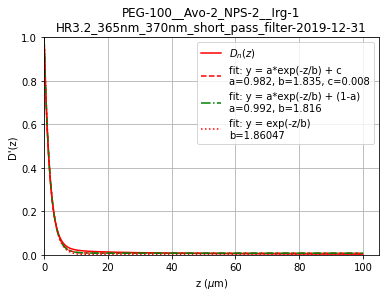

In [19]:
# Source
source_365nm_shortpass = data.sources['HR3.2_365nm_370nm_short_pass_filter-2019-12-31']

# Irradiance
irradiance_365_shortpass = Irradiance(source=source_365nm_shortpass, resin=resin, wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose = NormalizedDose(irradiance=irradiance_365_shortpass, z_array_params=z_array_params)

norm_dose.plot(title=(norm_dose.irradiance.resin.name + "\n" + norm_dose.irradiance.source.name));
# plt.savefig('NormDose_365nm_source.png')


# Create filtered 385 nm source

In [4]:
wavelengths = np.linspace(*ArrayParams(300, 440, 281))

source_385nm = data.sources['HR2_385nm_2020-03-23']
source_385nm_filtered = copy.deepcopy(source_385nm)
# source_385nm_filtered.power = np.array(source_385nm.power)
index_380nm = find_index_of_nearest(source_385nm_filtered.wavelength, 380)

print(index_380nm, source_385nm_filtered.power[index_380nm-1], source_385nm_filtered.power[index_380nm])

source_385nm_filtered.power[:index_380nm] = 0
print(index_380nm, source_385nm_filtered.power[index_380nm-1], source_385nm_filtered.power[index_380nm])


index_390nm = find_index_of_nearest(source_385nm_filtered.wavelength, 390)
source_385nm_filtered.power[index_390nm:] = 0
source_385nm_filtered.name = source_385nm_filtered.name + '_filtered'

print(source_385nm.power[index_390nm])
print(source_385nm_filtered.power[index_390nm])

1134 0.7249001766927191 0.744715423972231
1134 0.0 0.744715423972231
0.2524776425256319
0.0


## Plot 365 nm and filtered 385 nm sources

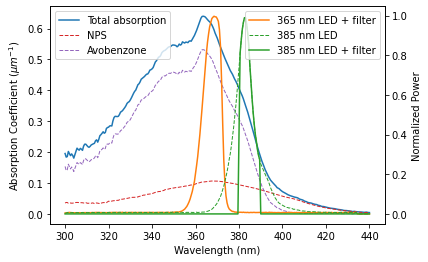

In [35]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(wavelengths, resin.calc_absorption_coef_inv_um(wavelengths), label='Total absorption')
ax.plot(wavelengths, resin_nps.calc_absorption_coef_inv_um(wavelengths), c='C3', lw=1, ls='--', label='NPS')
ax.plot(wavelengths, resin_avo.calc_absorption_coef_inv_um(wavelengths), c='C4', lw=1, ls='--', label='Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
# ax.set_title(nps.name + '\n' + source.name)
ax2.plot(wavelengths, source_365nm_shortpass.calc_power(wavelengths), c='C1', label='365 nm LED + filter')
ax2.plot(wavelengths, source_385nm.calc_power(wavelengths), c='C2', lw=1, ls='--', label='385 nm LED')
ax2.plot(wavelengths, source_385nm_filtered.calc_power(wavelengths), c='C2', label='385 nm LED + filter')
ax2.set_ylabel('Normalized Power')
ax.legend(loc='upper left')
ax2.legend(loc='upper right');

# plt.savefig('365nm_385nm_sources.png')


## Normalized dose for filtered 385 nm source

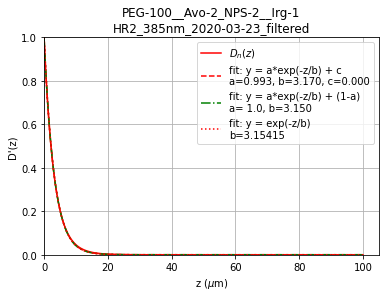

In [21]:
# Irradiance
irradiance_385_filtered = Irradiance(source=source_385nm_filtered, resin=resin, wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose_385_filtered = NormalizedDose(irradiance=irradiance_385_filtered, z_array_params=z_array_params)

norm_dose_385_filtered.plot(title=(norm_dose_385_filtered.irradiance.resin.name + "\n" + norm_dose_385_filtered.irradiance.source.name));

# plt.savefig('NormDose_385nm_filtered_source.png')



## Unfiltered 385 nm source

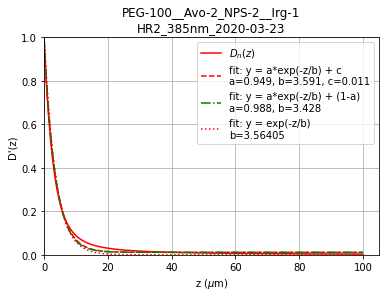

In [28]:
# Irradiance
irradiance_385 = Irradiance(source=source_385nm, 
                            resin=resin, 
                            wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose_385 = NormalizedDose(irradiance=irradiance_385, z_array_params=z_array_params)

norm_dose_385.plot(title=(norm_dose_395.irradiance.resin.name + "\n" + norm_dose_385.irradiance.source.name));

# plt.savefig('NormDose_385nm_source.png')



# Shift 385 nm source to 395 nm

def shift(arr, num, fill_value=0):
    # shift5 from gzc's answer at
    # https://stackoverflow.com/questions/30399534/shift-elements-in-a-numpy-array
    result = np.empty_like(arr)
    if num > 0:
        result[:num] = fill_value
        result[num:] = arr[:-num]
    elif num < 0:
        result[num:] = fill_value
        result[:num] = arr[-num:]
    else:
        result[:] = arr
    return result

def shift_peak_wavelength(new_peak_wavelength, original_wavelengths, original_power):
    index_peak_wavelength = find_index_of_max(original_power)
    index_new_peak_wavelength = find_index_of_nearest(original_wavelengths, new_peak_wavelength)
    delta_index = index_new_peak_wavelength - index_peak_wavelength
    return shift(original_power, delta_index)

In [8]:
length = 10
shift_right = 4

temp = np.array([x + 1 for x in range(length)])
print(temp)

print(shift(temp, shift_right))
print(shift(temp, -shift_right))

[ 1  2  3  4  5  6  7  8  9 10]
[0 0 0 0 1 2 3 4 5 6]
[ 5  6  7  8  9 10  0  0  0  0]


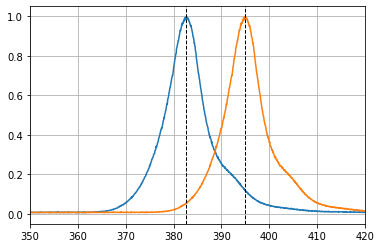

In [12]:
source_395nm = copy.deepcopy(source_385nm)

source_395nm.power = shift_peak_wavelength(395, source_395nm.wavelength, source_395nm.power)

fig, ax = plt.subplots()
ax.plot(source_385nm.wavelength, source_385nm.power)
ax.plot(source_395nm.wavelength, source_395nm.power)
ax.set_xlim(350, 420)

index_max = find_index_of_max(source_385nm.power)

ax.axvline(source_385nm.wavelength[index_max], c='k', ls='--', lw=1)
ax.axvline(395, c='k', ls='--', lw=1)
ax.grid()

# Shift filtered 385 nm source to 395 nm

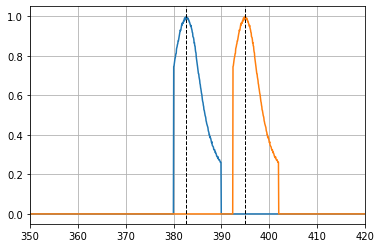

In [14]:
source_395nm_filtered = copy.deepcopy(source_385nm_filtered)

source_395nm_filtered.power = shift_peak_wavelength(395, 
                                                    source_395nm_filtered.wavelength, 
                                                    source_395nm_filtered.power)
source_395nm_filtered.name = source_395nm_filtered.name + '_shift_to_395nm'

fig, ax = plt.subplots()
ax.plot(source_385nm_filtered.wavelength, source_385nm_filtered.power)
ax.plot(source_395nm_filtered.wavelength, source_395nm_filtered.power)
ax.set_xlim(350, 420)

index_max = find_index_of_max(source_385nm_filtered.power)

ax.axvline(source_385nm_filtered.wavelength[index_max], c='k', ls='--', lw=1)
ax.axvline(395, c='k', ls='--', lw=1)
ax.grid()

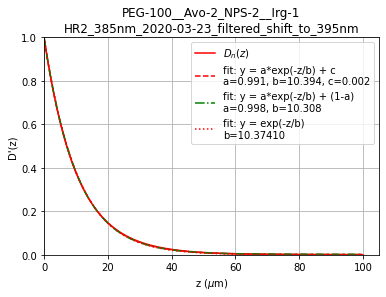

In [22]:
# Irradiance
irradiance_395_filtered = Irradiance(source=source_395nm_filtered, 
                                     resin=resin, 
                                     wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose_395_filtered = NormalizedDose(irradiance=irradiance_395_filtered, z_array_params=z_array_params)

norm_dose_395_filtered.plot(title=(norm_dose_395_filtered.irradiance.resin.name + "\n" + norm_dose_395_filtered.irradiance.source.name));

# plt.savefig('NormDose_395nm_filtered_source.png')



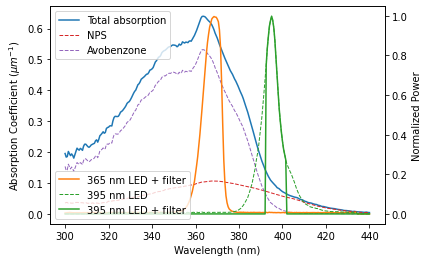

In [37]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(wavelengths, resin.calc_absorption_coef_inv_um(wavelengths), label='Total absorption')
ax.plot(wavelengths, resin_nps.calc_absorption_coef_inv_um(wavelengths), c='C3', lw=1, ls='--', label='NPS')
ax.plot(wavelengths, resin_avo.calc_absorption_coef_inv_um(wavelengths), c='C4', lw=1, ls='--', label='Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
# ax.set_title(nps.name + '\n' + source.name)
ax2.plot(wavelengths, source_365nm_shortpass.calc_power(wavelengths), c='C1', label='365 nm LED + filter')
ax2.plot(wavelengths, source_395nm.calc_power(wavelengths), c='C2', lw=1, ls='--', label='395 nm LED')
ax2.plot(wavelengths, source_395nm_filtered.calc_power(wavelengths), c='C2', label='395 nm LED + filter')
ax2.set_ylabel('Normalized Power')
ax.legend(loc='upper left')
ax2.legend(loc='lower left');

# plt.savefig('365nm_395nm_sources.png')


# Shift unfiltered 385 nm source to 395 nm

## Create 395 nm source

In [24]:
source_395nm = copy.deepcopy(source_385nm)

source_395nm.power = shift_peak_wavelength(395, 
                                            source_395nm.wavelength, 
                                            source_395nm.power)
source_395nm.name = source_395nm.name + '_shift_to_395nm'


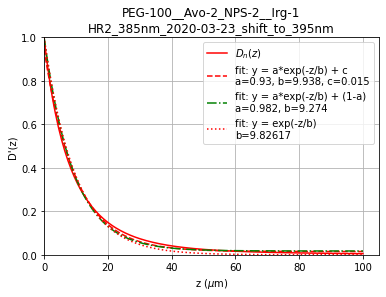

In [26]:
# Irradiance
irradiance_395 = Irradiance(source=source_395nm, 
                            resin=resin, 
                            wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose_395 = NormalizedDose(irradiance=irradiance_395, z_array_params=z_array_params)

norm_dose_395.plot(title=(norm_dose_395.irradiance.resin.name + "\n" + norm_dose_395.irradiance.source.name));

# plt.savefig('NormDose_395nm_source.png')

